In [5]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. 注册所有的模型路径
# ==========================================
BASE_DIR = "/NAS/shith/uplift/results/criteo/"

# ⚠️ 这里把你的所有新旧模型都列出来
MODELS_TO_EVALUATE = {
    "V1_Base": f"{BASE_DIR}train_y/TARNET/y_v1_base/**/test_dist.csv",
    "MT_Naive_Small": f"{BASE_DIR}train_y/TARNET/y_v1_naive_mt_small_c_weight/**/test_dist.csv",
    "MT_Naive_Large": f"{BASE_DIR}train_y/TARNET/y_v1_naive_mt_larger_c_weight/**/test_dist.csv",
    "MOTTO_KDD25": f"{BASE_DIR}train_y/MOTTO/y_motto/motto_kdd25_official_20260409/**/test_dist.csv",
    "MTMT": f"{BASE_DIR}train_y/MTMT/**/test_dist.csv", # 假设路径
    "ECUP": f"{BASE_DIR}train_y/ECUP/**/test_dist.csv", # 假设路径
    "V7_Conflict_Gold": f"{BASE_DIR}train_y/TARNET/y_v7_conflict_gold/**/test_dist.csv",
    "V8_S1_T10": f"{BASE_DIR}train_y/TARNET/y_v8_s1_t10/**/test_dist.csv",
    "V9_DRO": f"{BASE_DIR}train_y/TARNET/y_v9_dro_a_coarse/**/test_dist.csv",
    "V10_Both": f"{BASE_DIR}train_y/TARNET/y_v10_conflict_both/**/test_dist.csv",
    "Model_C_Independent": f"{BASE_DIR}train_c/TARNET/c_v1_base/**/test_dist.csv"
}

# ==========================================
# 2. 核心算子：局部 AUUC 与 ATE
# ==========================================
def compute_local_auuc(y_s, t_s):
    if len(y_s) < 2: return 0.0
    n_t = np.cumsum(t_s == 1); n_c = np.cumsum(t_s == 0)
    y_t = np.cumsum(y_s * (t_s == 1)); y_c = np.cumsum(y_s * (t_s == 0))
    n_t_safe = np.where(n_t == 0, 1e-6, n_t)
    n_c_safe = np.where(n_c == 0, 1e-6, n_c)
    
    with np.errstate(invalid='ignore', divide='ignore'):
        curve = (y_t / n_t_safe - y_c / n_c_safe) * (n_t + n_c)
    curve = np.nan_to_num(curve)
    if abs(curve[-1]) > 1e-10: curve = curve / abs(curve[-1])
    return float(np.trapz(curve, dx=1.0/len(y_s)))

def get_lift(y_s, t_s):
    if len(y_s) == 0: return 0.0
    return (np.sum(y_s[t_s == 1]) / (np.sum(t_s == 1) + 1e-9)) - (np.sum(y_s[t_s == 0]) / (np.sum(t_s == 0) + 1e-9))

# ==========================================
# 3. 扫描数据并提取多维特征
# ==========================================
print("🚀 正在加载所有模型预测数据...")
data_dict = {}
results = []

for name, pattern in MODELS_TO_EVALUATE.items():
    files = glob.glob(pattern, recursive=True)
    if not files: continue
    
    df = pd.read_csv(files[0])
    data_dict[name] = df.copy()
    
    # 全局降序，计算大一统排行榜指标
    df_sorted = df.sort_values(by='uplift_pred', ascending=False).reset_index(drop=True)
    y_t, t_t = df_sorted['y_true'].values, df_sorted['t'].values
    n = len(y_t)
    
    # 抽取 C 的预测能力 (如果有的话)
    c_auuc = 0.0
    if 'c_uplift_pred' in df_sorted.columns:
        df_c_sorted = df.sort_values(by='c_uplift_pred', ascending=False).reset_index(drop=True)
        c_auuc = compute_local_auuc(df_c_sorted['c_true'].values, df_c_sorted['t'].values)
    
    res = {
        "Model": name,
        "Y_AUUC_Global": compute_local_auuc(y_t, t_t),
        "C_AUUC_Global": c_auuc, # 看看多任务有没有把 C 学好
        "Lift@5 (Head)": get_lift(y_t[:int(n*0.05)], t_t[:int(n*0.05)]),
        "Lift@20 (Torso)": get_lift(y_t[:int(n*0.20)], t_t[:int(n*0.20)]),
        "Local_AUUC [20-100] (Tail)": compute_local_auuc(y_t[int(n*0.20):], t_t[int(n*0.20):])
    }
    results.append(res)

df_leaderboard = pd.DataFrame(results).sort_values(by="Y_AUUC_Global", ascending=False)
pd.set_option('display.float_format', '{:.5f}'.format)
print("\n" + "="*120)
print("🏆 【多任务 vs 复杂网络】全系模型终极大考排行榜")
print("="*120)
print(df_leaderboard.to_string(index=False))



🚀 正在加载所有模型预测数据...

🏆 【多任务 vs 复杂网络】全系模型终极大考排行榜
              Model  Y_AUUC_Global  C_AUUC_Global  Lift@5 (Head)  Lift@20 (Torso)  Local_AUUC [20-100] (Tail)
          V8_S1_T10        0.91473        0.00000        0.01334          0.00498                     0.91838
   V7_Conflict_Gold        0.91188        0.00000        0.01294          0.00496                     0.81384
           V10_Both        0.90994        0.00000        0.01351          0.00512                     0.62460
             V9_DRO        0.90892        0.00000        0.01384          0.00511                     0.49529
               ECUP        0.89366        0.85421        0.01266          0.00495                     0.40162
        MOTTO_KDD25        0.89092        0.00000        0.01290          0.00495                     0.49118
            V1_Base        0.88393        0.00000        0.01073          0.00491                     0.49334
               MTMT        0.88117        0.82396        0.01207          

In [ ]:
df_c = pd.read_csv('')

In [ ]:
# 还是符合预期的，就是中介模型头部好，但是尾巴不好。
# 相关性和散点图，有趣，好像可以看Y uplift和C uplift的关系，V78910可以把输入的作为C uplift,/NAS/shith/uplift/results/criteo/train_c/TARNET/c_v1_base/exp_c_explore/test_dist.csv从这里读取y0_prob,y1_prob变量名没改，实际上是中介。因为是先验嘛，不过有ground truth吗，如果有，怎么样，如果没有可能得用细化策略，因为我们还要看它换了血对性能的影响。
# 换血要细化，要去看各个人群换血到底换到什么程度了。而不仅是现在的。

# formal

🚀 正在扫描文件并计算各维度的 Lift 与 Local AUUC...

📊 第一步：各区间 Lift 与 Local AUUC 大满贯全景表
         Model  Lift@5  Lift@10  Lift@20  AUUC [0-100%]  AUUC [0-5%]  AUUC [0-10%]  AUUC [10-20%]  AUUC [0-20%]  AUUC [20-50%]  AUUC [50-100%]  AUUC [20-100%]
       V1_Base  0.0107   0.0086   0.0049         0.8839       0.6942        0.6326         0.8321        0.7576         0.5302          0.4022          0.4933
MT_Naive_Small  0.0117   0.0084   0.0048         0.8796       0.6180        0.6607         0.6093        0.7590         0.7100          0.2629          0.5036
MT_Naive_Large  0.0124   0.0082   0.0049         0.8800       0.6749        0.6970         0.6482        0.7648         0.5820          0.2764          0.5015
MOTTO_Official  0.0129   0.0081   0.0050         0.8909       0.7048        0.7231         0.6653        0.7631         0.3421          0.4595          0.4912
          MTMT  0.0121   0.0089   0.0050         0.8812       0.6002        0.6281         0.8175        0.7600         0.5259      

/tmp/ipykernel_1572032/2702231827.py:152: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=col, y="Model", data=plot_data, ax=ax, palette="viridis")
/tmp/ipykernel_1572032/2702231827.py:152: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=col, y="Model", data=plot_data, ax=ax, palette="viridis")
/tmp/ipykernel_1572032/2702231827.py:152: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=col, y="Model", data=plot_data, ax=ax, palette="viridis")
/tmp/ipykernel_1572032/2702231827.py:152: FutureWarning: 

Passing `palette` without assigning `hue` is

✅ AUUC 切片对比图已生成: 0414_analyze/step1_auuc_comparison.png


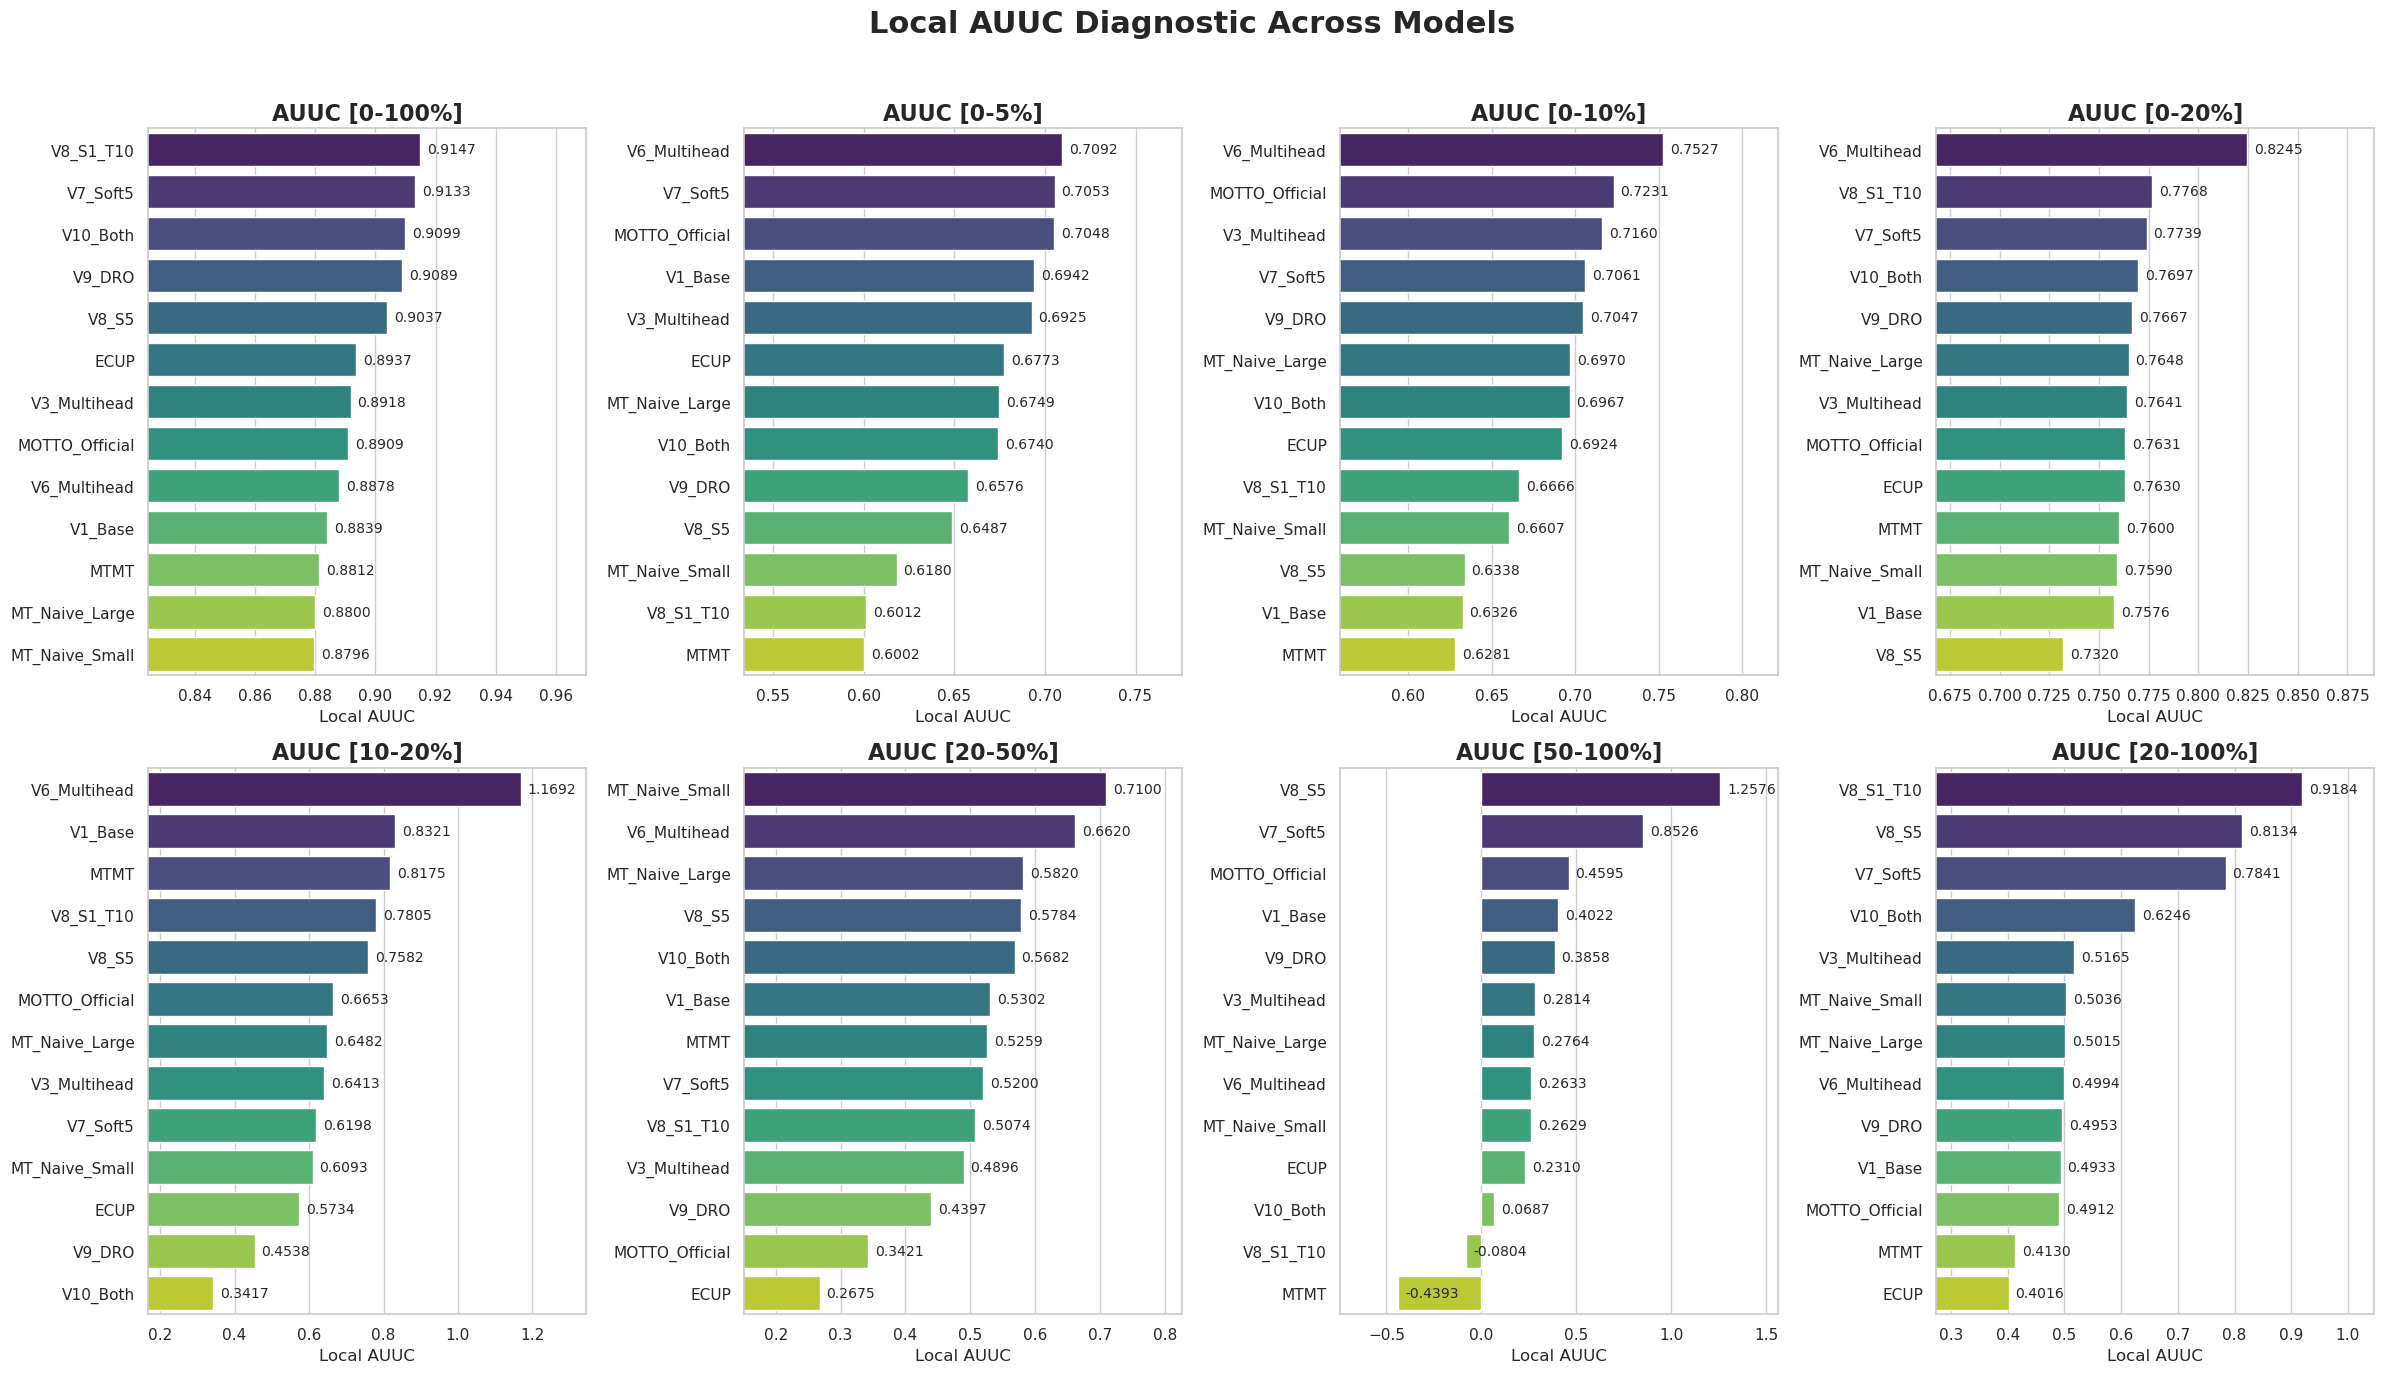

In [14]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. 初始化设置与路径管理
# ==========================================
OUTPUT_DIR = "0414_analyze"
os.makedirs(OUTPUT_DIR, exist_ok=True)

BASE_DIR = "/NAS/shith/uplift/results/criteo/train_y/"

# 收录你提到的所有 baseline 和 multitask 最新模型
MODELS_TO_EVALUATE = {
    "V1_Base": f"{BASE_DIR}TARNET/y_v1_base/**/test_dist.csv",
    "MT_Naive_Small": f"{BASE_DIR}TARNET/y_v1_naive_mt_small_c_weight/**/test_dist.csv",
    "MT_Naive_Large": f"{BASE_DIR}TARNET/y_v1_naive_mt_larger_c_weight/**/test_dist.csv",
    "MOTTO_Official": f"{BASE_DIR}MOTTO/y_motto/motto_kdd25_official_20260409/**/test_dist.csv",
    "MTMT": f"{BASE_DIR}MTMT/**/test_dist.csv", # 请根据实际子文件夹结构调整
    "ECUP": f"{BASE_DIR}ECUP/**/test_dist.csv", # 请根据实际子文件夹结构调整,
    "V3_Multihead": f"{BASE_DIR}TARNET/y_v3_moe/**/test_dist.csv",
    'V6_Multihead':f"{BASE_DIR}TARNET/y_v6_res_moe/**/test_dist.csv", 
    "V7_Soft5": f"{BASE_DIR}TARNET/y_v7_soft_top5/**/test_dist.csv",
    "V8_S1_T10": f"{BASE_DIR}TARNET/y_v8_s1_t10/**/test_dist.csv",
    "V8_S5": f"{BASE_DIR}TARNET/y_v8_s5/**/test_dist.csv",
    "V9_DRO": f"{BASE_DIR}TARNET/y_v9_dro_a_coarse/**/test_dist.csv",
    "V10_Both": f"{BASE_DIR}TARNET/y_v10_conflict_both/**/test_dist.csv"
}

# ==========================================
# 2. 核心算子：局部 AUUC 与 Lift 计算
# ==========================================
def compute_local_auuc(y_s, t_s):
    if len(y_s) < 2: return 0.0
    n_t = np.cumsum(t_s == 1)
    n_c = np.cumsum(t_s == 0)
    y_t = np.cumsum(y_s * (t_s == 1))
    y_c = np.cumsum(y_s * (t_s == 0))
    
    n_t_safe = np.where(n_t == 0, 1e-6, n_t)
    n_c_safe = np.where(n_c == 0, 1e-6, n_c)
    
    with np.errstate(invalid='ignore', divide='ignore'):
        curve = (y_t / n_t_safe - y_c / n_c_safe) * (n_t + n_c)
    curve = np.nan_to_num(curve)
    
    # 绝对值归一化，防止尾部负数导致曲线翻转
    endpoint = curve[-1]
    if abs(endpoint) > 1e-10:
        curve = curve / abs(endpoint)
        
    x_axis = np.arange(1, len(y_s) + 1) / len(y_s)
    return float(np.trapz(curve, x=x_axis))

def get_lift(y_true_sorted, t_sorted, k_pct):
    idx = int(len(y_true_sorted) * k_pct / 100.0)
    if idx == 0: return 0.0
    
    y_s = y_true_sorted[:idx]
    t_s = t_sorted[:idx]
    
    cr_t = np.sum(y_s[t_s == 1]) / (np.sum(t_s == 1) + 1e-9)
    cr_c = np.sum(y_s[t_s == 0]) / (np.sum(t_s == 0) + 1e-9)
    return float(cr_t - cr_c)

def get_slice_auuc(y_true_sorted, t_sorted, start_pct, end_pct):
    n = len(y_true_sorted)
    s_idx = int(n * start_pct / 100.0)
    e_idx = int(n * end_pct / 100.0)
    return compute_local_auuc(y_true_sorted[s_idx:e_idx], t_sorted[s_idx:e_idx])

# ==========================================
# 3. 数据扫描与指标提取
# ==========================================
print(f"🚀 正在扫描文件并计算各维度的 Lift 与 Local AUUC...")
results = []

for name, pattern in MODELS_TO_EVALUATE.items():
    files = glob.glob(pattern, recursive=True)
    if not files: 
        print(f"⚠️ 找不到模型: {name} (匹配路径: {pattern})")
        continue
        
    try:
        df = pd.read_csv(files[0])
        # 全局强制按模型自己的 uplift 预测降序！
        df = df.sort_values(by='uplift_pred', ascending=False).reset_index(drop=True)
        y_t = df['y_true'].values
        t_t = df['t'].values
        
        row = {
            "Model": name,
            "Lift@5": get_lift(y_t, t_t, 5),
            "Lift@10": get_lift(y_t, t_t, 10),
            "Lift@20": get_lift(y_t, t_t, 20),
            "AUUC [0-100%]": get_slice_auuc(y_t, t_t, 0, 100),
            "AUUC [0-5%]": get_slice_auuc(y_t, t_t, 0, 5),
            "AUUC [0-10%]": get_slice_auuc(y_t, t_t, 0, 10),
            "AUUC [10-20%]": get_slice_auuc(y_t, t_t, 10, 20),
            "AUUC [0-20%]": get_slice_auuc(y_t, t_t, 0, 20),
            "AUUC [20-50%]": get_slice_auuc(y_t, t_t, 20, 50),
            "AUUC [50-100%]": get_slice_auuc(y_t, t_t, 50, 100),
            "AUUC [20-100%]": get_slice_auuc(y_t, t_t, 20, 100)
        }
        results.append(row)
    except Exception as e:
        print(f"❌ 读取 {name} 失败: {e}")

df_res = pd.DataFrame(results)

# 打印并落盘表单
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1500)
pd.set_option('display.float_format', '{:.4f}'.format)

print("\n" + "="*140)
print("📊 第一步：各区间 Lift 与 Local AUUC 大满贯全景表")
print("="*140)
print(df_res.to_string(index=False))
print("="*140)

csv_path = os.path.join(OUTPUT_DIR, "step1_metrics_full.csv")
df_res.to_csv(csv_path, index=False)
print(f"✅ 全景表已保存至: {csv_path}")


# ==========================================
# 4. 可视化：AUUC 多维对比图 (你要的画图)
# ==========================================
print("\n🎨 正在绘制 AUUC 切片对比图...")

# 我们把这 7 个 AUUC 切片分为两组画图：头部聚焦区 vs 腰尾深水区
auuc_cols_head = ['AUUC [0-100%]', "AUUC [0-5%]", "AUUC [0-10%]", "AUUC [0-20%]"]
auuc_cols_tail = ["AUUC [10-20%]", "AUUC [20-50%]", "AUUC [50-100%]", "AUUC [20-100%]"]

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 4, figsize=(24, 14))
fig.suptitle("Local AUUC Diagnostic Across Models", fontsize=22, fontweight='bold', y=0.98)

# 铺平 axes 方便遍历
axes_flat = axes.flatten()
all_auuc_cols = auuc_cols_head + auuc_cols_tail

for i, col in enumerate(all_auuc_cols):
    ax = axes_flat[i]
    # 对当前指标排个序，画出来更直观
    plot_data = df_res[["Model", col]].sort_values(by=col, ascending=False)
    
    sns.barplot(x=col, y="Model", data=plot_data, ax=ax, palette="viridis")
    ax.set_title(col, fontsize=16, fontweight='bold')
    ax.set_xlabel("Local AUUC", fontsize=12)
    ax.set_ylabel("")
    
    # 动态微调 X 轴以放大差异
    min_val, max_val = plot_data[col].min(), plot_data[col].max()
    margin = (max_val - min_val) * 0.15 + 0.05
    ax.set_xlim(min_val - margin, max_val + margin)
    
    # 把具体数值打在柱子上
    for p in ax.patches:
        width = p.get_width()
        ax.annotate(f'{width:.4f}', (width, p.get_y() + p.get_height() / 2.), 
                    ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=10)

# 隐藏最后一个空着的 subplot (7个指标，8个格子)
# axes_flat[-1].axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plot_path = os.path.join(OUTPUT_DIR, "step1_auuc_comparison.png")
plt.savefig(plot_path, dpi=300)
print(f"✅ AUUC 切片对比图已生成: {plot_path}")

In [6]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. 初始化设置与路径管理 (与 Step 1 保持一致)
# ==========================================
OUTPUT_DIR = "0414_analyze"
os.makedirs(OUTPUT_DIR, exist_ok=True)

BASE_DIR = "/NAS/shith/uplift/results/criteo/train_y/"

# 收录所有 baseline 和 multitask 最新模型
MODELS_TO_EVALUATE = {
    "V1_Base": f"{BASE_DIR}TARNET/y_v1_base/**/test_dist.csv",
    "MT_Naive_Small": f"{BASE_DIR}TARNET/y_v1_naive_mt_small_c_weight/**/test_dist.csv",
    "MT_Naive_Large": f"{BASE_DIR}TARNET/y_v1_naive_mt_larger_c_weight/**/test_dist.csv",
    "MOTTO_Official": f"{BASE_DIR}MOTTO/y_motto/motto_kdd25_official_20260409/**/test_dist.csv",
    "MTMT": f"{BASE_DIR}MTMT/**/test_dist.csv", 
    "ECUP": f"{BASE_DIR}ECUP/**/test_dist.csv",
    "V3_Multihead": f"{BASE_DIR}TARNET/y_v3_moe/**/test_dist.csv",
    "V6_Multihead": f"{BASE_DIR}TARNET/y_v6_res_moe/**/test_dist.csv", 
    "V7_Soft5": f"{BASE_DIR}TARNET/y_v7_soft_top5/**/test_dist.csv",
    "V8_S1_T10": f"{BASE_DIR}TARNET/y_v8_s1_t10/**/test_dist.csv",
    "V9_DRO": f"{BASE_DIR}TARNET/y_v9_dro_a_coarse/**/test_dist.csv",
    "V10_Both": f"{BASE_DIR}TARNET/y_v10_conflict_both/**/test_dist.csv"
}

# ==========================================
# 2. 新增核心算子：计算用于绘图的归一化曲线点
# ==========================================
def compute_uplift_curve_points(y_s, t_s):
    """
    计算并在视觉上归一化用于绘图的 Uplift (Qini) 曲线点
    """
    if len(y_s) < 2: return np.array([]), np.array([]), 0.0
    n_t_cum = np.cumsum(t_s == 1)
    n_c_cum = np.cumsum(t_s == 0)
    y_t_cum = np.cumsum(y_s * (t_s == 1))
    y_c_cum = np.cumsum(y_s * (t_s == 0))
    
    n_t_safe = np.where(n_t_cum == 0, 1e-6, n_t_cum)
    n_c_safe = np.where(n_c_cum == 0, 1e-6, n_c_cum)
    
    with np.errstate(invalid='ignore', divide='ignore'):
        # 复制用户 Step 2 原始算法: (Y_T / N_T - Y_C / N_C) * (N_T + N_C)
        curve = (y_t_cum / n_t_safe - y_c_cum / n_c_safe) * (n_t_cum + n_c_cum)
    curve = np.nan_to_num(curve)
    
    # 🌟 核心：复制 Step 2 的绝对值归一化逻辑，确保图中面积分数(AUUC)与标量数据完全对应
    endpoint = curve[-1]
    if abs(endpoint) > 1e-10:
        curve = curve / abs(endpoint)
        
    x_axis = np.arange(1, len(y_s) + 1) / len(y_s)
    auuc_score = float(np.trapz(curve, x=x_axis))
    return x_axis, curve, auuc_score


# ==========================================
# 4. 可视化：为每个模型生成多维 AUUC 曲线拼图 (你要的画图)
# ==========================================
print("\n🎨 正在为每个模型生成单独的归一化 AUUC 曲线拼图 (Qini 曲线)...")

# 定义您代码中精确使用的 8 个 AUUC 指标对应的具体区间定义
# 这 8 个指标刚好可以排成 2 行 x 4 列 的拼图网格
auuc_slices_config = [
    ("0-100%", 0, 100), # 全局参考
    ("0-5%", 0, 5),
    ("0-10%", 0, 10),
    ("0-20%", 0, 20),
    ("10-20%", 10, 20),
    ("20-50%", 20, 50),
    ("50-100%", 50, 100),
    ("20-100%", 20, 100)
]

sns.set_theme(style="white") # white grid is less distracting for curves

# 循环模型，每个模型单独存一张图
for name, pattern in MODELS_TO_EVALUATE.items():
    files = glob.glob(pattern, recursive=True)
    if not files: continue
        
    try:
        df = pd.read_csv(files[0])
        # 强制按模型自己的 uplift 预测值全局降序！
        df = df.sort_values(by='uplift_pred', ascending=False).reset_index(drop=True)
        y_all = df['y_true'].values
        t_all = df['t'].values
        n_total = len(y_all)
        
        # 创建一个 2行 x 4列 的拼图，每个模型一张
        fig, axes = plt.subplots(2, 4, figsize=(24, 12), sharex=False, sharey=False)
        fig.suptitle(f"AUUC (Qini) Diagnostic Curves: {name}\n(Normalized & Diagnostic Slices)", fontsize=22, fontweight='bold', y=0.98)
        axes_flat = axes.flatten()

        for i, (slice_name, start_pct, end_pct) in enumerate(auuc_slices_config):
            ax = axes_flat[i]
            
            # 物理切片数据
            s_idx = int(n_total * start_pct / 100.0)
            e_idx = int(n_total * end_pct / 100.0)
            y_s = y_all[s_idx:e_idx]
            t_s = t_all[s_idx:e_idx]
            
            # 计算曲线点和分数
            x, curve_points, auuc_val = compute_uplift_curve_points(y_s, t_s)
            
            if len(x) > 0:
                # 绘制 Qini 曲线 (已归一化)
                ax.plot(x, curve_points, label='Model Curve', color='#1f77b4', linewidth=2.5)
                
                # 添加随机基线：从 (0,0) 到 (1, 归一化 endpoint)
                endpoint_norm = curve_points[-1]
                ax.plot([0, 1], [0, endpoint_norm], linestyle='--', color='gray', label='Random Baseline')
                
                # 填充区域以突出 AUC (诊断性)
                ax.fill_between(x, curve_points, color='#1f77b4', alpha=0.1) 
                
                # 格式化 subplot
                # 标题采用您代码中的标题形式，加分值
                ax.set_title(f"AUUC [{slice_name}]\n(Score={auuc_val:.4f})", fontsize=15, fontweight='bold')
                # ax.legend(fontsize=10, loc='lower right')
                ax.set_xlabel("Population Ratio in Slice", fontsize=12)
                ax.set_ylabel("Normalized Qini Gain", fontsize=12)
                ax.grid(True, linestyle='--', alpha=0.6)

        # 隐藏任何多余的subplot（这里我们精确使用了8个，2x4网格正好填满）
        # axes_flat[-1].axis('off')

        plt.tight_layout(rect=[0, 0, 1, 0.95])
        
        # 为每个模型单独保存
        plot_path = os.path.join(OUTPUT_DIR, f"{name}_auuc_diagnostic_curves.png")
        plt.savefig(plot_path, dpi=300)
        plt.close(fig) # 极其重要：关闭 figure 防止内存泄漏
        print(f"✅ 模型 '{name}' 的 AUUC 曲线拼图已生成: {plot_path}")

    except Exception as e:
        print(f"❌ 读取 {name} 进行曲线绘制时失败: {e}")


🎨 正在为每个模型生成单独的归一化 AUUC 曲线拼图 (Qini 曲线)...
✅ 模型 'V1_Base' 的 AUUC 曲线拼图已生成: 0414_analyze/V1_Base_auuc_diagnostic_curves.png
✅ 模型 'MT_Naive_Small' 的 AUUC 曲线拼图已生成: 0414_analyze/MT_Naive_Small_auuc_diagnostic_curves.png
✅ 模型 'MT_Naive_Large' 的 AUUC 曲线拼图已生成: 0414_analyze/MT_Naive_Large_auuc_diagnostic_curves.png
✅ 模型 'MOTTO_Official' 的 AUUC 曲线拼图已生成: 0414_analyze/MOTTO_Official_auuc_diagnostic_curves.png
✅ 模型 'MTMT' 的 AUUC 曲线拼图已生成: 0414_analyze/MTMT_auuc_diagnostic_curves.png
✅ 模型 'ECUP' 的 AUUC 曲线拼图已生成: 0414_analyze/ECUP_auuc_diagnostic_curves.png
✅ 模型 'V3_Multihead' 的 AUUC 曲线拼图已生成: 0414_analyze/V3_Multihead_auuc_diagnostic_curves.png
✅ 模型 'V6_Multihead' 的 AUUC 曲线拼图已生成: 0414_analyze/V6_Multihead_auuc_diagnostic_curves.png
✅ 模型 'V7_Soft5' 的 AUUC 曲线拼图已生成: 0414_analyze/V7_Soft5_auuc_diagnostic_curves.png
✅ 模型 'V8_S1_T10' 的 AUUC 曲线拼图已生成: 0414_analyze/V8_S1_T10_auuc_diagnostic_curves.png
✅ 模型 'V9_DRO' 的 AUUC 曲线拼图已生成: 0414_analyze/V9_DRO_auuc_diagnostic_curves.png
✅ 模型 'V10_Both' 的 AUUC 曲线拼图已生成: 041

In [9]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. 路径与配置
# ==========================================
OUTPUT_DIR = "0414_analyze_curves"
os.makedirs(OUTPUT_DIR, exist_ok=True)

BASE_DIR = "/NAS/shith/uplift/results/criteo/train_y/"

# 独立 C 模型 (作为 V1~V10 的 Pred C 来源)
C_PRIOR_PATH = "/NAS/shith/uplift/results/criteo/train_c/TARNET/c_v1_base/exp_c_explore/test_dist.csv"

# 你的所有模型
MODELS_TO_EVALUATE = {
    "V1_Base": f"{BASE_DIR}TARNET/y_v1_base/**/test_dist.csv",
    "MT_Naive_Small": f"{BASE_DIR}TARNET/y_v1_naive_mt_small_c_weight/**/test_dist.csv",
    "MT_Naive_Large": f"{BASE_DIR}TARNET/y_v1_naive_mt_larger_c_weight/**/test_dist.csv",
    "MOTTO_Official": f"{BASE_DIR}MOTTO/y_motto/motto_kdd25_official_20260409/**/test_dist.csv",
    "MTMT": f"{BASE_DIR}MTMT/**/test_dist.csv", 
    "ECUP": f"{BASE_DIR}ECUP/**/test_dist.csv",
    "V3_Multihead": f"{BASE_DIR}TARNET/y_v3_moe/**/test_dist.csv",
    "V6_Multihead": f"{BASE_DIR}TARNET/y_v6_res_moe/**/test_dist.csv", 
    "V7_Soft5": f"{BASE_DIR}TARNET/y_v7_soft_top5/**/test_dist.csv",
    "V8_S1_T10": f"{BASE_DIR}TARNET/y_v8_s1_t10/**/test_dist.csv",
    "V9_DRO": f"{BASE_DIR}TARNET/y_v9_dro_a_coarse/**/test_dist.csv",
    "V10_Both": f"{BASE_DIR}TARNET/y_v10_conflict_both/**/test_dist.csv"
}

SLICES = [(0, 5), (5, 10), (10, 20), (20, 30), (30, 40), (40, 50), (50, 75), (75, 100)]
SLICE_LABELS = [f"{s}-{e}%" for s, e in SLICES]

# ==========================================
# 2. 预加载独立 C 模型的预测 (Ground Truth 长度对齐)
# ==========================================
print("📥 正在加载独立 C 模型先验...")
c_file = glob.glob(C_PRIOR_PATH, recursive=True)[0]
df_c_indep = pd.read_csv(c_file)
# 独立的 Pred C 就是它预测的 y1_prob - y0_prob
INDEP_C_PRED = df_c_indep['y1_prob'] - df_c_indep['y0_prob']

def get_ate(y_s, t_s):
    if len(y_s) == 0: return 0.0
    cr_t = np.sum(y_s[t_s == 1]) / (np.sum(t_s == 1) + 1e-9)
    cr_c = np.sum(y_s[t_s == 0]) / (np.sum(t_s == 0) + 1e-9)
    return float(cr_t - cr_c)

# ==========================================
# 3. 数据扫描与绘图 (告别表格，全部可视化)
# ==========================================
print("\n🎨 正在为所有模型生成【四线趋势图】...")

for name, pattern in MODELS_TO_EVALUATE.items():
    files = glob.glob(pattern, recursive=True)
    if not files: 
        print(f"⚠️ 跳过 {name} (未找到文件)")
        continue
        
    df = pd.read_csv(files[0])
    
    # 🌟 核心逻辑：智能分配 Pred C
    if 'c_uplift_pred' in df.columns:
        # 多任务模型 (MTMT, ECUP, MOTTO等)，用它自己预测的 C
        df['Final_Pred_C'] = df['c_uplift_pred']
    else:
        # 两阶段模型 (V1, V7-V10)，用我们从独立 C 读出来的先验
        df['Final_Pred_C'] = INDEP_C_PRED
        
    # 必须按当前模型预测的 Y Uplift 降序排列！
    df = df.sort_values(by='uplift_pred', ascending=False).reset_index(drop=True)
    
    y_true = df['y_true'].values
    c_true = df['c_true'].values
    t = df['t'].values
    pred_y = df['uplift_pred'].values
    pred_c = df['Final_Pred_C'].values
    
    n_total = len(df)
    
    # 收集 4 个核心指标的趋势
    trend_true_y, trend_true_c = [], []
    trend_pred_y, trend_pred_c = [], []
    
    for start, end in SLICES:
        s_idx, e_idx = int(n_total * start / 100), int(n_total * end / 100)
        
        trend_true_y.append(get_ate(y_true[s_idx:e_idx], t[s_idx:e_idx]))
        trend_true_c.append(get_ate(c_true[s_idx:e_idx], t[s_idx:e_idx]))
        trend_pred_y.append(pred_y[s_idx:e_idx].mean())
        trend_pred_c.append(pred_c[s_idx:e_idx].mean())
        
    # === 开始画图 ===
    plt.figure(figsize=(12, 6))
    sns.set_theme(style="whitegrid")
    
    x = np.arange(len(SLICES))
    
    # 画 Y 相关的线 (红色系)
    plt.plot(x, trend_true_y, color='#d62728', marker='o', linewidth=3, markersize=8, label='True Uplift Y (Real Conv)')
    plt.plot(x, trend_pred_y, color='#d62728', marker='x', linestyle='--', linewidth=2, label='Pred Uplift Y (Model Est)')
    
    # 画 C 相关的线 (蓝色系)
    plt.plot(x, trend_true_c, color='#1f77b4', marker='s', linewidth=3, markersize=8, label='True Uplift C (Real Click)')
    plt.plot(x, trend_pred_c, color='#1f77b4', marker='^', linestyle='--', linewidth=2, label='Pred Uplift C (Prior/MTL Est)')
    
    # 0 轴基准线
    plt.axhline(0, color='black', linewidth=1, linestyle='-')
    
    plt.title(f"Mechanism Tracking: {name}\n(Y-Calibration vs C-Dependency)", fontsize=16, fontweight='bold', pad=15)
    plt.xlabel("Population Slices (Sorted by Pred Y)", fontsize=12)
    plt.ylabel("Uplift Value", fontsize=12)
    plt.xticks(x, SLICE_LABELS)
    
    # 把图例放在外面防止遮挡曲线
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    
    plt.tight_layout()
    out_path = os.path.join(OUTPUT_DIR, f"Trend_{name}.png")
    plt.savefig(out_path, dpi=300)
    plt.close()
    print(f"✅ 生成 {name} 的四线趋势图: {out_path}")

print("\n🎉 所有折线图已存入 0414_analyze_curves 文件夹，赶快去翻看对比吧！")

📥 正在加载独立 C 模型先验...

🎨 正在为所有模型生成【四线趋势图】...
✅ 生成 V1_Base 的四线趋势图: 0414_analyze_curves/Trend_V1_Base.png
✅ 生成 MT_Naive_Small 的四线趋势图: 0414_analyze_curves/Trend_MT_Naive_Small.png
✅ 生成 MT_Naive_Large 的四线趋势图: 0414_analyze_curves/Trend_MT_Naive_Large.png
✅ 生成 MOTTO_Official 的四线趋势图: 0414_analyze_curves/Trend_MOTTO_Official.png
✅ 生成 MTMT 的四线趋势图: 0414_analyze_curves/Trend_MTMT.png
✅ 生成 ECUP 的四线趋势图: 0414_analyze_curves/Trend_ECUP.png
✅ 生成 V3_Multihead 的四线趋势图: 0414_analyze_curves/Trend_V3_Multihead.png
✅ 生成 V6_Multihead 的四线趋势图: 0414_analyze_curves/Trend_V6_Multihead.png
✅ 生成 V7_Soft5 的四线趋势图: 0414_analyze_curves/Trend_V7_Soft5.png
✅ 生成 V8_S1_T10 的四线趋势图: 0414_analyze_curves/Trend_V8_S1_T10.png
✅ 生成 V9_DRO 的四线趋势图: 0414_analyze_curves/Trend_V9_DRO.png
✅ 生成 V10_Both 的四线趋势图: 0414_analyze_curves/Trend_V10_Both.png

🎉 所有折线图已存入 0414_analyze_curves 文件夹，赶快去翻看对比吧！


In [12]:
import os
import glob
import pandas as pd
import numpy as np
from scipy.stats import spearmanr, pearsonr

# ==========================================
# 1. 路径与配置 (复用之前的配置)
# ==========================================
BASE_DIR = "/NAS/shith/uplift/results/criteo/train_y/"
C_PRIOR_PATH = "/NAS/shith/uplift/results/criteo/train_c/TARNET/c_v1_base/exp_c_explore/test_dist.csv"

MODELS_TO_EVALUATE = {
    "V1_Base": f"{BASE_DIR}TARNET/y_v1_base/**/test_dist.csv",
    "MT_Naive_Small": f"{BASE_DIR}TARNET/y_v1_naive_mt_small_c_weight/**/test_dist.csv",
    "MT_Naive_Large": f"{BASE_DIR}TARNET/y_v1_naive_mt_larger_c_weight/**/test_dist.csv",
    "MOTTO_Official": f"{BASE_DIR}MOTTO/y_motto/motto_kdd25_official_20260409/**/test_dist.csv",
    "MTMT": f"{BASE_DIR}MTMT/**/test_dist.csv", 
    "ECUP": f"{BASE_DIR}ECUP/**/test_dist.csv",
    "V3_Multihead": f"{BASE_DIR}TARNET/y_v3_moe/**/test_dist.csv",
    "V6_Multihead": f"{BASE_DIR}TARNET/y_v6_res_moe/**/test_dist.csv", 
    "V7_Soft5": f"{BASE_DIR}TARNET/y_v7_soft_top5/**/test_dist.csv",
    "V8_S1_T10": f"{BASE_DIR}TARNET/y_v8_s1_t10/**/test_dist.csv",
    "V9_DRO": f"{BASE_DIR}TARNET/y_v9_dro_a_coarse/**/test_dist.csv",
    "V10_Both": f"{BASE_DIR}TARNET/y_v10_conflict_both/**/test_dist.csv"
}

# ==========================================
# 2. 提取 C 的独立先验
# ==========================================
print("📥 正在加载独立 C 模型先验...")
c_file = glob.glob(C_PRIOR_PATH, recursive=True)[0]
df_c_indep = pd.read_csv(c_file)
INDEP_C_PRED = df_c_indep['y1_prob'] - df_c_indep['y0_prob']

# ==========================================
# 3. 计算相关性
# ==========================================
print("🧬 正在进行模型心智的基因测序 (计算 Y 与 C 的预测相关性)...")

results = []

for name, pattern in MODELS_TO_EVALUATE.items():
    files = glob.glob(pattern, recursive=True)
    if not files: 
        continue
        
    df = pd.read_csv(files[0])
    
    # 智能分配 Pred C
    if 'c_uplift_pred' in df.columns:
        pred_c = df['c_uplift_pred'].values
    else:
        pred_c = INDEP_C_PRED.values
        
    pred_y = df['uplift_pred'].values
    
    # 计算 Spearman (秩相关/排位相关性) 和 Pearson (线性/数值相关性)
    # 我们更看重 Spearman，因为它代表模型给用户排序的心智是否完全一致
    spearman_corr, _ = spearmanr(pred_y, pred_c)
    pearson_corr, _ = pearsonr(pred_y, pred_c)
    
    results.append({
        "Model": name,
        "Spearman (排位纠缠度)": spearman_corr,
        "Pearson (数值纠缠度)": pearson_corr,
    })

df_corr = pd.DataFrame(results)

# 按排位纠缠度降序排序
df_corr = df_corr.sort_values(by="Spearman (排位纠缠度)", ascending=False).reset_index(drop=True)

# 打印美化后的报表
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1500)
pd.set_option('display.float_format', '{:.4f}'.format)

print("\n" + "="*120)
print("🧬 【预测心智测序】: 模型预测 Y_Uplift 与 C_Uplift 的相关性排行榜")
print("="*120)
print(df_corr.to_string(index=False))
print("="*120)
print("\n💡 解读指南：")
print("1. 如果 MT_Naive_Large 的相关性极高，说明主任务被辅任务彻底带偏了（负迁移）。")
print("2. V8 或 V10 的相关性如果能降到 0.5 ~ 0.8 之间，这是最完美的。说明它参考了 C，但有自己独立的 Y 预测视角！")

📥 正在加载独立 C 模型先验...
🧬 正在进行模型心智的基因测序 (计算 Y 与 C 的预测相关性)...

🧬 【预测心智测序】: 模型预测 Y_Uplift 与 C_Uplift 的相关性排行榜
         Model  Spearman (排位纠缠度)  Pearson (数值纠缠度)
MOTTO_Official            0.7717           0.6188
  V3_Multihead            0.7579           0.7258
      V7_Soft5            0.6966           0.6188
          MTMT            0.6811           0.7149
          ECUP            0.6630           0.4894
     V8_S1_T10            0.6358           0.6695
  V6_Multihead            0.5726           0.3898
MT_Naive_Small            0.5241           0.5054
      V10_Both            0.4623           0.5962
MT_Naive_Large            0.2532          -0.0852
        V9_DRO            0.0596           0.5516
       V1_Base           -0.1027           0.5666

💡 解读指南：
1. 如果 MT_Naive_Large 的相关性极高，说明主任务被辅任务彻底带偏了（负迁移）。
2. V8 或 V10 的相关性如果能降到 0.5 ~ 0.8 之间，这是最完美的。说明它参考了 C，但有自己独立的 Y 预测视角！
